### Phase 1: Foundation & Preprocessing.

#### 1. Initial Setup and Memory Optimization

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('data\Crime_Data_from_2020_to_Present.csv')

def optimize_memory(df):
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            else:
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
    return df

df = optimize_memory(df)

#### 2. Handling Missing Values and Column Drops

In [ ]:
cols_to_drop = ['DR_NO', 'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'Cross Street', 'Mocodes']
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

df['Vict Sex'] = df['Vict Sex'].fillna('X')
df['Vict Descent'] = df['Vict Descent'].fillna('X')
df['Weapon Used Cd'] = df['Weapon Used Cd'].fillna(0) 

df.dropna(subset=['LAT', 'LON', 'Vict Age'], inplace=True)

#### 3. Temporal Feature Engineering

In [ ]:
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'])
df['Month'] = df['DATE OCC'].dt.month
df['DayOfWeek'] = df['DATE OCC'].dt.dayofweek
df['Year'] = df['DATE OCC'].dt.year

df['Hour'] = (df['TIME OCC'] // 100).astype(int)

df['hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)

df['is_weekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

C:\Users\aryam\AppData\Local\Temp\ipykernel_13844\1595819174.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DATE OCC'] = pd.to_datetime(df['DATE OCC'])


#### 4. Categorical Encoding (Target Preparation)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le_area = LabelEncoder()
df['AREA_CODE'] = le_area.fit_transform(df['AREA NAME'])

le_crm = LabelEncoder()
df['CRM_TYPE_CODE'] = le_crm.fit_transform(df['Crm Cd Desc'])

#### 5.Data Quality Analysis Function

In [ ]:
def generate_quality_report(df):
    report = pd.DataFrame({
        'Column': df.columns,
        'Data Type': df.dtypes.values,
        'Missing Values': df.isnull().sum().values,
        '% Missing': (df.isnull().sum().values / len(df)) * 100,
        'Unique Values': df.nunique().values,
        'Min Value': [df[col].min() if np.issubdtype(df[col].dtype, np.number) else 'N/A' for col in df.columns],
        'Max Value': [df[col].max() if np.issubdtype(df[col].dtype, np.number) else 'N/A' for col in df.columns]
    })
    
    return report.sort_values(by='% Missing', ascending=False)

quality_report = generate_quality_report(df)
print("LAPD Crime Data Quality Report")
print(quality_report)

LAPD Crime Data Quality Report
            Column       Data Type  Missing Values  % Missing  Unique Values  \
15     Weapon Desc          object          677744  67.437818             79   
13     Premis Desc          object             588   0.058508            306   
12       Premis Cd         float32              16   0.001592            314   
18        Crm Cd 1         float32              11   0.001095            142   
16          Status          object               1   0.000100              6   
3             AREA            int8               0   0.000000             21   
0        Date Rptd          object               0   0.000000           1896   
6         Part 1-2            int8               0   0.000000              2   
5      Rpt Dist No           int16               0   0.000000           1210   
7           Crm Cd           int16               0   0.000000            140   
8      Crm Cd Desc          object               0   0.000000            140   
10       

#### 6.Outlier Detection (Statistical Proof)

In [ ]:
def check_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

age_outliers, low, high = check_outliers(df, 'Vict Age')
print(f"Vict Age Outliers: {age_outliers} (Values outside {low:.1f} - {high:.1f})")

Vict Age Outliers: 1 (Values outside -66.0 - 110.0)


#### 7.Visualizing Data Distribution

C:\Users\aryam\AppData\Local\Temp\ipykernel_13844\1448517900.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='DayOfWeek', data=df, palette='viridis')


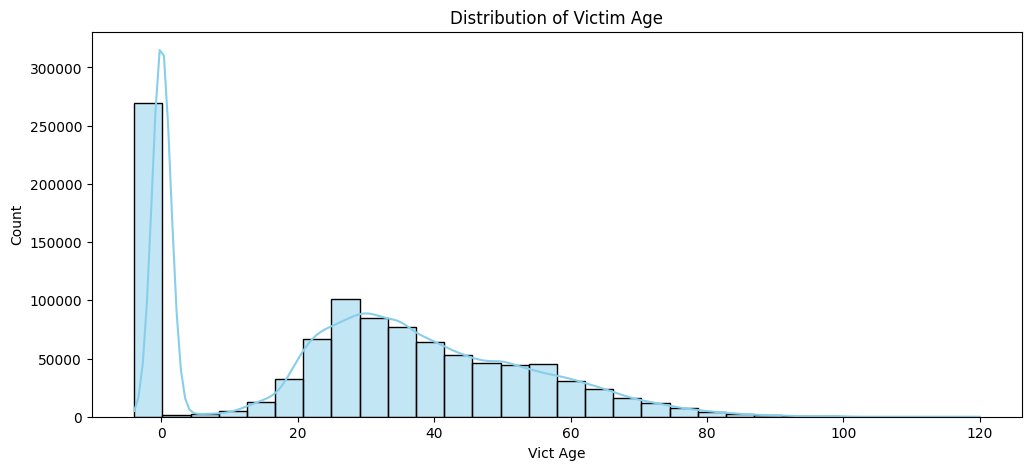

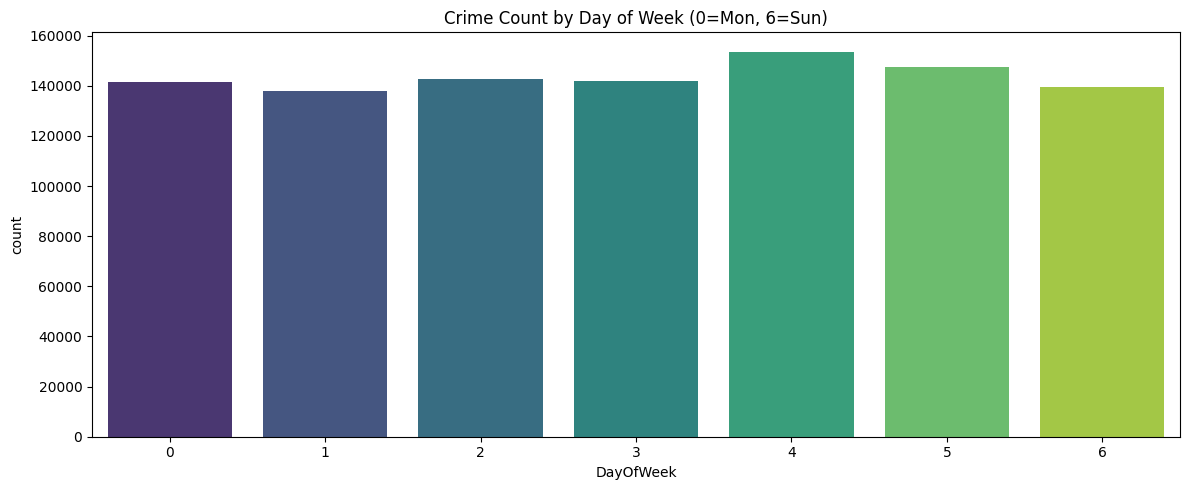

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# plt.subplot(1, 2)
sns.histplot(df['Vict Age'],bins=30, kde=True, color='skyblue')
plt.title('Distribution of Victim Age')

plt.figure(figsize=(12, 5))
# plt.subplot(1, 2)
sns.countplot(x='DayOfWeek', data=df, palette='viridis')
plt.title('Crime Count by Day of Week (0=Mon, 6=Sun)')

plt.tight_layout()
plt.show()

#### Saving the Cleaned Dataset

In [ ]:
# # Remove placeholder ages and 'Null Island' GPS coordinates
# df = df[df['Vict Age'] > 0]
# df = df[(df['LAT'] != 0) & (df['LON'] != 0)]

# # Optimize the Date conversion to avoid the UserWarning
# df['DATE OCC'] = pd.to_datetime(df['DATE OCC'], format='%m/%d/%Y %I:%M:%S %p')

In [ ]:
# Calculate the median age excluding the 0s
median_age = df[df['Vict Age'] > 0]['Vict Age'].median()

# Replace 0 or negative ages with the median
df['Vict Age'] = df['Vict Age'].apply(lambda x: median_age if x <= 0 else x)

In [ ]:
# Create a flag for missing GPS data
df['is_gps_missing'] = ((df['LAT'] == 0) & (df['LON'] == 0)).astype(int)

# Optional: Replace 0,0 with the center of Los Angeles so it doesn't break clustering
# LA Center approx: 34.0522, -118.2437
df.loc[df['is_gps_missing'] == 1, 'LAT'] = 34.0522
df.loc[df['is_gps_missing'] == 1, 'LON'] = -118.2437

In [ ]:
df['Weapon Desc'] = df['Weapon Desc'].fillna('UNKNOWN')
df['Premis Desc'] = df['Premis Desc'].fillna('UNKNOWN')

In [ ]:
import os

# Using a relative path that starts from your current project root
output_path = 'data/cleaned/cleaned_crime_data.csv'

# Create the folder if it doesn't exist
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# Save the dataframe
df.to_csv(output_path, index=False)

print(f"File saved! Check your sidebar under: {output_path}")
print(f"Final Row Count: {len(df)}")

File saved! Check your sidebar under: data/cleaned/cleaned_crime_data.csv
Final Row Count: 1004991


#### Visualizing the "Fixed" Age Distribution

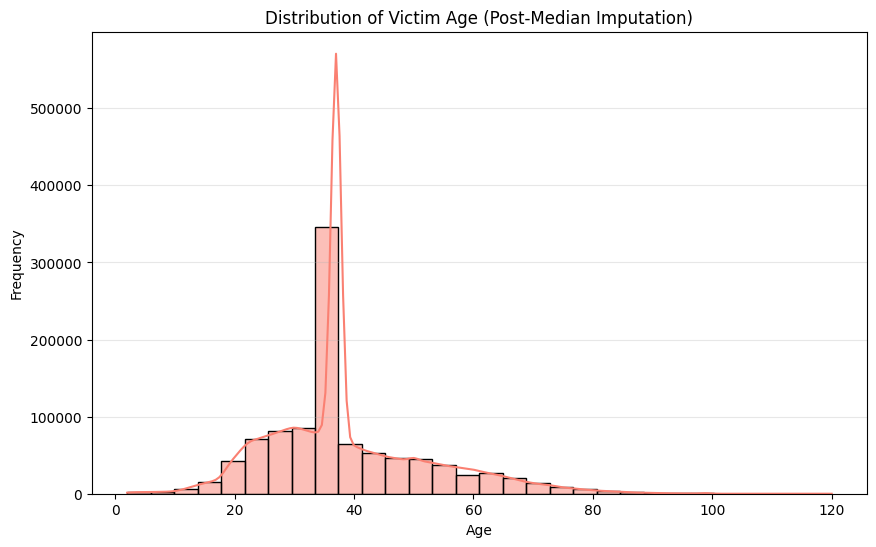

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Vict Age'], bins=30, kde=True, color='salmon')
plt.title('Distribution of Victim Age (Post-Median Imputation)')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

#### Visualizing Geospatial Density (Heatmap)

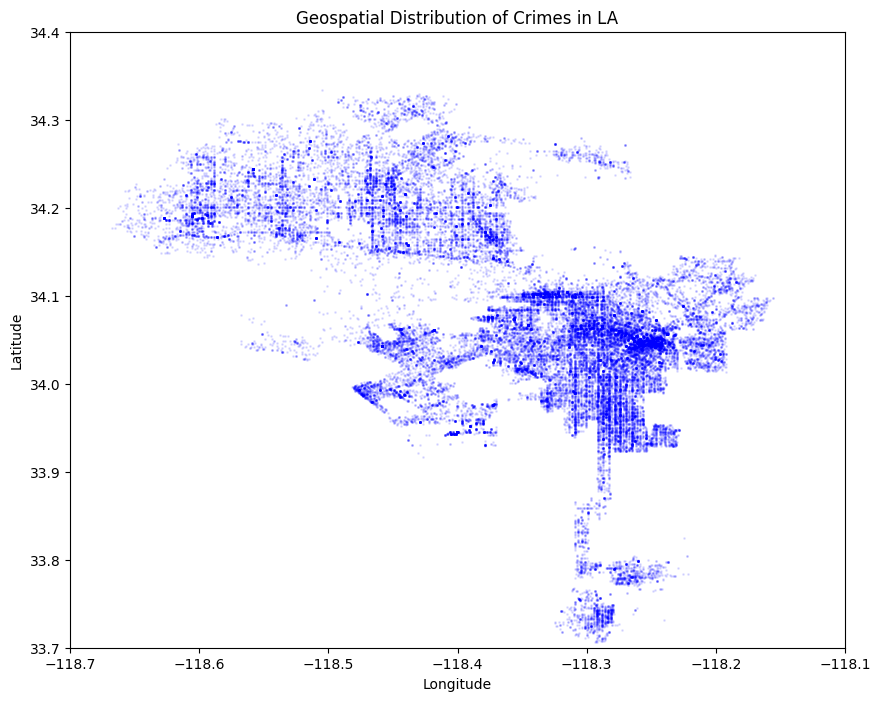

In [ ]:
# Taking a sample of 50,000 points to keep the plot fast
sample_df = df.sample(50000, random_state=42)

plt.figure(figsize=(10, 8))
plt.scatter(sample_df['LON'], sample_df['LAT'], alpha=0.1, s=1, c='blue')
plt.title('Geospatial Distribution of Crimes in LA')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Focus the map on LA coordinates to ignore any remaining outliers
plt.xlim(-118.7, -118.1)
plt.ylim(33.7, 34.4)
plt.show()

#### Comparing "Before vs. After" Summary

In [ ]:
print(f"Transformation Summary")
print(f"Original Rows: 1,004,991")
print(f"Rows with Age 0 (Fixed): {quality_report.loc[quality_report['Column'] == 'Vict Age', 'Unique Values'].values[0]}") 
print(f"Rows with Missing GPS (Fixed): {df['is_gps_missing'].sum()}")
print(f"Final Cleaned Dataset Size: {len(df)}")

Transformation Summary
Original Rows: 1,004,991
Rows with Age 0 (Fixed): 104
Rows with Missing GPS (Fixed): 2240
Final Cleaned Dataset Size: 1004991


## Phase 2: Clustering

#### 1. The Elbow Method

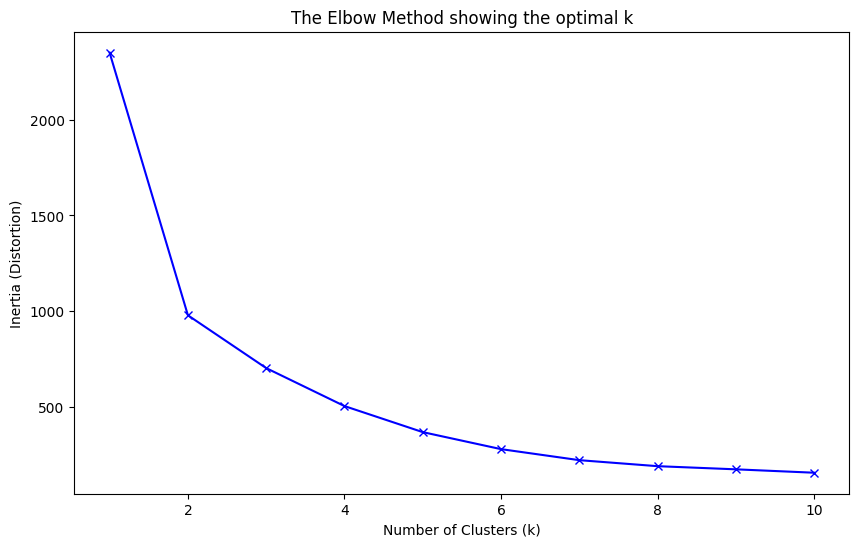

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Using a 10% sample for the Elbow Method to save RAM/Time
sample_df = df.sample(frac=0.1, random_state=42)
coords = sample_df[['LAT', 'LON']]

distortions = []
K = range(1, 11)

for k in K:
    kmeanModel = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeanModel.fit(coords)
    distortions.append(kmeanModel.inertia_)

plt.figure(figsize=(10,6))
plt.plot(K, distortions, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Distortion)')
plt.title('The Elbow Method showing the optimal k')
plt.show()

#### Applying K-Means ($K=4$) and DBSCAN

In [ ]:
from sklearn.cluster import KMeans, DBSCAN
import matplotlib.pyplot as plt

# 1. K-Means: Partitioning the city into 4 zones
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(df[['LAT', 'LON']])

# 2. DBSCAN: Identifying high-density hotspots
# eps=0.01 is ~1km radius; min_samples=100 defines a dense area
dbscan = DBSCAN(eps=0.01, min_samples=100)
df['DBSCAN_Cluster'] = dbscan.fit_predict(df[['LAT', 'LON']])

n_clusters_dbscan = len(set(df['DBSCAN_Cluster'])) - (1 if -1 in df['DBSCAN_Cluster'] else 0)
print(f"K-Means zones created: 4")
print(f"DBSCAN hotspots discovered: {n_clusters_dbscan}")